In [41]:
import pandas as pd

In [42]:
data = pd.read_csv('Titanic-Dataset.csv')

In [43]:
data.drop(columns=['Name','Cabin'], inplace=True, errors="ignore")

In [44]:
data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,female,35.0,1,0,113803,53.1000,S
4,5,0,3,male,35.0,0,0,373450,8.0500,S


In [45]:
data.shape

(891, 10)

In [46]:
data.describe(include = 'all')

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
count,891.000000,891.000000,891.000000,891,714.000000,891.000000,891.000000,891,891.000000,889
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,681,NaN,3
top,NaN,NaN,NaN,male,NaN,NaN,NaN,347082,NaN,S
freq,NaN,NaN,NaN,577,NaN,NaN,NaN,7,NaN,644
mean,446.000000,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN
std,257.353842,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN
min,1.000000,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN
25%,223.500000,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN
50%,446.000000,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN
75%,668.500000,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN


In [47]:
data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,female,35.0,1,0,113803,53.1000,S
4,5,0,3,male,35.0,0,0,373450,8.0500,S


In [48]:
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [49]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [ ]:
notnull_age = data.loc[data['Age'].notnull(), 'Age']
notnull_age_mean = notnull_age.mean()
data.loc[data['Age'].isnull(), 'Age'] = notnull_age_mean

In [51]:

data.loc[data['Embarked'].isnull(), 'Embarked'] = data['Embarked'].mode()

<Axes: xlabel='Survived', ylabel='Count'>

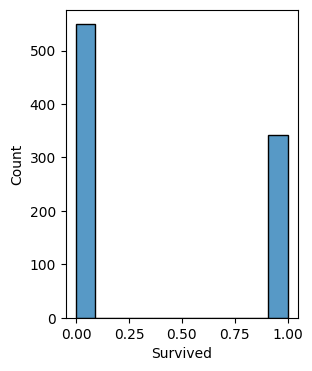

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3,4))
sns.histplot(x='Survived', data=data)

In [55]:
data = pd.get_dummies(data, drop_first= True, dtype = int)

In [56]:
data.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Ticket_110413,Ticket_110465,...,Ticket_W./C. 14258,Ticket_W./C. 14263,Ticket_W./C. 6607,Ticket_W./C. 6608,Ticket_W./C. 6609,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,0,...,0,0,0,0,0,0,0,0,0,1


In [58]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['Survived'])
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [59]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    print(f'k: {k}, Train Score: {knn.score(X_train, y_train)}, Test Score: {knn.score(X_test, y_test)}')

cm = confusion_matrix(y_test, knn.predict(X_test))
print(cm)

k: 1, Train Score: 1.0, Test Score: 0.5977653631284916
k: 2, Train Score: 0.8075842696629213, Test Score: 0.6201117318435754
k: 3, Train Score: 0.8033707865168539, Test Score: 0.5865921787709497
k: 4, Train Score: 0.7471910112359551, Test Score: 0.6312849162011173
k: 5, Train Score: 0.7556179775280899, Test Score: 0.659217877094972
k: 6, Train Score: 0.7247191011235955, Test Score: 0.6536312849162011
k: 7, Train Score: 0.7219101123595506, Test Score: 0.6536312849162011
k: 8, Train Score: 0.7008426966292135, Test Score: 0.6424581005586593
k: 9, Train Score: 0.7036516853932584, Test Score: 0.6480446927374302
k: 10, Train Score: 0.6980337078651685, Test Score: 0.6480446927374302
k: 11, Train Score: 0.6882022471910112, Test Score: 0.6480446927374302
k: 12, Train Score: 0.6867977528089888, Test Score: 0.6424581005586593
k: 13, Train Score: 0.6938202247191011, Test Score: 0.6368715083798883
k: 14, Train Score: 0.6924157303370787, Test Score: 0.6480446927374302
k: 15, Train Score: 0.691011235